In [1]:
# Install required packages (idempotent, safe to re-run)
import sys
!{sys.executable} -m pip install --quiet lightgbm scikit-learn pandas numpy matplotlib joblib

# EXP H Threshold Experiment

Threshold sweep for: `0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2` using the same EXP3 preprocessing/model bundle.

In [2]:
from pathlib import Path

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# -- Utility helpers (mirrors Main_2015_Training_Core + EXP3-B) --------------

def _find_col(columns, aliases):
    lc = {c.lower(): c for c in columns}
    for a in aliases:
        if a.lower() in lc:
            return lc[a.lower()]
    for c in columns:
        if any(a.lower() in c.lower() for a in aliases):
            return c
    return None

def _to_num(s):
    return pd.to_numeric(s, errors='coerce').replace([9, 99, 888888, 999999], np.nan)

def _build_smoking_level(df_):
    sl = _find_col(df_.columns, ['smoking_level'])
    if sl:
        return _to_num(df_[sl]).clip(0, 3).astype(float), [sl]
    ss  = _find_col(df_.columns, ['smoke_status'])
    cs  = _find_col(df_.columns, ['current_smoking', 'currentsmoking'])
    es  = _find_col(df_.columns, ['ever_smk'])
    used, out = [], pd.Series(np.nan, index=df_.index, dtype=float)
    if ss:
        status = _to_num(df_[ss]); used.append(ss)
        out[status == 0] = 0; out[status == 2] = 1; out[status == 1] = 2
        if cs:
            cur = _to_num(df_[cs]); used.append(cs)
            out[(status == 1) & (cur == 3)] = 3
        return out, used
    if cs:
        cur = _to_num(df_[cs]); used.append(cs)
        out[cur == 0] = 0; out[cur.isin([1, 2])] = 2; out[cur == 3] = 3
        return out, used
    if es:
        ever = _to_num(df_[es]); used.append(es)
        out[ever == 0] = 0; out[ever > 0] = 1
        return out, used
    return None, []

def _build_alcohol_level(df_):
    al = _find_col(df_.columns, ['alcohol_level'])
    if al:
        return _to_num(df_[al]).clip(0, 3).astype(float), [al]
    as_ = _find_col(df_.columns, ['alcohol_status'])
    bg  = _find_col(df_.columns, ['binge_drink', 'binge_drinking'])
    ca  = _find_col(df_.columns, ['con_alcohol'])
    d30 = _find_col(df_.columns, ['drnk_30days'])
    ae  = _find_col(df_.columns, ['alcohol'])
    used, out = [], pd.Series(np.nan, index=df_.index, dtype=float)
    if as_:
        status = _to_num(df_[as_]); used.append(as_)
        out[status == 0] = 0; out[status == 2] = 1; out[status == 1] = 2
        if bg:
            binge = _to_num(df_[bg]); used.append(bg)
            out[(status == 1) & (binge == 1)] = 3
        return out, used
    out[:] = 0
    if ae:
        ever = _to_num(df_[ae]);   used.append(ae);   out[ever > 0] = 1
    if ca:
        cur  = _to_num(df_[ca]);   used.append(ca);   out[cur == 1] = np.maximum(out[cur == 1], 2)
    if d30:
        d    = _to_num(df_[d30]);  used.append(d30);  out[d == 1]   = np.maximum(out[d == 1], 2)
    if bg:
        b    = _to_num(df_[bg]);   used.append(bg);   out[b == 1]   = 3
    return (out, used) if used else (None, [])

def _build_bmi(df_):
    w = _find_col(df_.columns, ['weight'])
    h = _find_col(df_.columns, ['height'])
    if not w or not h:
        return None, []
    wt = pd.to_numeric(df_[w], errors='coerce')
    ht = pd.to_numeric(df_[h], errors='coerce')
    if pd.notna(ht.median()) and float(ht.median()) > 3.0:
        ht = ht / 100.0
    return (wt / ht**2).replace([np.inf, -np.inf], np.nan).astype(float), [w, h]

def _build_whr(df_):
    wc = _find_col(df_.columns, ['waist'])
    hc = _find_col(df_.columns, ['hip'])
    if not wc or not hc:
        return None, []
    waist = pd.to_numeric(df_[wc], errors='coerce')
    hip   = pd.to_numeric(df_[hc], errors='coerce').replace(0, np.nan)
    return (waist / hip).replace([np.inf, -np.inf], np.nan).astype(float), [wc, hc]

# -- Merge from Datasets2015 (mirrors Main_2015_Training_Core merge logic) -----
CWD = Path.cwd()
if (CWD / 'Datasets2015').exists():
    ROOT = CWD
elif (CWD / 'FINAL' / 'Datasets2015').exists():
    ROOT = CWD / 'FINAL'
elif (CWD.parent / 'Datasets2015').exists():
    ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Could not locate Datasets2015. Run this notebook from FINAL or its parent folder."
    )
DS = ROOT / 'Datasets2015'

def _find_dataset(folder, hint=''):
    folder = Path(folder)
    cands  = sorted([
        p for p in folder.glob('*.csv')
        if 'data-set' in p.name.lower() and 'dictionary' not in p.name.lower()
    ])
    return next((p for p in cands if hint in p.name.lower()), cands[0] if cands else None)

KEY_PRIORITY = [
    ['enns_year', 'hhnum', 'member_code'],
    ['hhnum', 'member_code'],
    ['enns_year', 'hhnum'],
    ['hhnum'],
]

def _best_keys(left, right):
    for keys in KEY_PRIORITY:
        if all(k in left.columns and k in right.columns for k in keys):
            return keys
    return []

clin_path = _find_dataset(DS / 'Clinical',       'clinical')
diet_path = _find_dataset(DS / 'Dietary',         'dietary')
anth_path = _find_dataset(DS / 'Anthropometric',  'anthrop')

if clin_path is None:
    raise FileNotFoundError(f'Clinical CSV not found in {DS}/Clinical/')

clin_raw = pd.read_csv(clin_path, low_memory=False)
diet_raw = pd.read_csv(diet_path, low_memory=False) if diet_path else None
anth_raw = pd.read_csv(anth_path, low_memory=False) if anth_path else None

# Left-join dietary onto clinical
df = clin_raw.copy()
if diet_raw is not None:
    merge_keys = _best_keys(df, diet_raw)
    if not merge_keys:
        raise ValueError('No common merge keys between clinical and dietary.')
    diet_work = diet_raw.drop_duplicates(subset=merge_keys, keep='first')
    overlap   = [c for c in diet_work.columns if c in df.columns and c not in merge_keys]
    diet_work = diet_work.drop(columns=overlap, errors='ignore')
    df        = df.merge(diet_work, on=merge_keys, how='left')
    print(f'After dietary merge : {df.shape}  keys={merge_keys}')

# Left-join anthropometric onto result
if anth_raw is not None:
    merge_keys = _best_keys(df, anth_raw)
    if merge_keys:
        anth_work = anth_raw.drop_duplicates(subset=merge_keys, keep='first')
        overlap   = [c for c in anth_work.columns if c in df.columns and c not in merge_keys]
        anth_work = anth_work.rename(columns={c: f'{c}_anth' for c in overlap})
        df        = df.merge(anth_work, on=merge_keys, how='left')
        print(f'After anthro merge  : {df.shape}  keys={merge_keys}')

print(f'Using data root    : {ROOT}')
print(f'Final merged shape : {df.shape}')

# -- Target engineering (Hypertension from SBP/DBP, mirrors Main_2015_Training_Core) --
sbp_col = _find_col(df.columns, ['ave_sbp', 'sbp', 'systolic', 'sysbp'])
dbp_col = _find_col(df.columns, ['ave_dbp', 'dbp', 'diastolic', 'diabp'])

if sbp_col and dbp_col:
    sbp = pd.to_numeric(df[sbp_col], errors='coerce')
    dbp = pd.to_numeric(df[dbp_col], errors='coerce')
    df['Hypertension'] = ((sbp >= 140) | (dbp >= 90)).fillna(False).astype(int)
    TARGET_COL = 'Hypertension'
    print(f'Target created from {sbp_col}, {dbp_col}  (>=140/90 rule)')
else:
    TARGET_COL = _find_col(df.columns, ['hypertension', 'htn', 'target', 'label', 'outcome'])
    if TARGET_COL is None:
        raise ValueError(f'Cannot derive target. Columns: {list(df.columns[:30])}')
    print(f'Target column found : {TARGET_COL}')

df = df.dropna(subset=[TARGET_COL]).copy()
print('Class balance:', df[TARGET_COL].value_counts(normalize=True).round(3).to_dict())

# -- Feature engineering (mirrors EXP3-B) --------------------------------------
X_raw = df.drop(columns=[TARGET_COL]).copy()
y     = df[TARGET_COL].astype(int).copy()

smk, smk_src = _build_smoking_level(X_raw)
if smk is not None:
    X_raw['fe_smoking_level'] = smk

alc, alc_src = _build_alcohol_level(X_raw)
if alc is not None:
    X_raw['fe_alcohol_level'] = alc

bmi, bmi_src = _build_bmi(X_raw)
if bmi is not None:
    X_raw['bmi'] = bmi

whr, whr_src = _build_whr(X_raw)
if whr is not None:
    X_raw['whr'] = whr

# -- Drop non-predictive / raw source columns (mirrors EXP3-B manual_non_predictive) --
DROP_ALWAYS = [
    sbp_col, dbp_col,
    'height', 'weight', 'waist', 'hip',
    'enns_year', 'hhnum', 'member_code',
    'regcode', 'provcode', 'psc', 'csc', 'rhc', 'psurec', 'strrec',
    'wgts', 'finalwgt', 'finalwgt1', 'finalwgt4',
    'rep_natl', 'rep_prov', 'ms_psucode', 'wrkplace',
    'interview_status', 'intdate', 'enumcode',
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num', 'alcohol_status',
    'binge_drinking', 'current_smoking', 'ever_smk', 'smoke_status', 'smoking_level', 'alcohol_level',
]
DROP_ALWAYS += list(set(bmi_src + whr_src + smk_src + alc_src))
lc_map = {c.lower(): c for c in X_raw.columns}
to_drop = sorted({lc_map[d.lower()] for d in DROP_ALWAYS if d and d.lower() in lc_map})
X_raw = X_raw.drop(columns=to_drop, errors='ignore')

# Deduplicate age/sex alias columns from anthro join
for _alias in ['age', 'sex']:
    _cands = [c for c in X_raw.columns if _alias in c.lower()]
    if len(_cands) > 1:
        _keep  = next((c for c in _cands if c.lower() == _alias), _cands[0])
        X_raw  = X_raw.drop(columns=[c for c in _cands if c != _keep], errors='ignore')

X = X_raw.copy()
print(f'Features: {X.shape[1]}  | Rows: {len(X)}  | Positives: {int(y.sum())}')


After dietary merge : (151189, 63)  keys=['hhnum']
After anthro merge  : (151189, 80)  keys=['hhnum', 'member_code']
Final merged shape  : (151189, 80)
Target created from Ave_SBP, Ave_DBP  (>=140/90 rule)
Class balance: {0: 0.848, 1: 0.152}
Features: 55  | Rows: 151189  | Positives: 22988


In [4]:
# ── EXP3-B style preprocessing: 3-way split + KNN impute + StandardScaler + OHE ──
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def _ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def e3_fit_imputers(X_tr, num_cols, cat_cols):
    knn = KNNImputer(n_neighbors=5)
    if num_cols:
        knn.fit(X_tr[num_cols])
    cat_imp = None
    if cat_cols:
        cat_imp = SimpleImputer(strategy='most_frequent')
        cat_imp.fit(X_tr[cat_cols])
    return knn, cat_imp

def e3_impute(knn, cat_imp, X_df, num_cols, cat_cols):
    frames = []
    if num_cols:
        frames.append(pd.DataFrame(knn.transform(X_df[num_cols]), columns=num_cols, index=X_df.index))
    if cat_cols and cat_imp is not None:
        frames.append(pd.DataFrame(cat_imp.transform(X_df[cat_cols]), columns=cat_cols, index=X_df.index))
    return pd.concat(frames, axis=1) if frames else pd.DataFrame(index=X_df.index)

def e3_fit_enc_scaler(X_imp, num_cols, cat_cols):
    scaler  = StandardScaler()
    ohe_enc = None
    if num_cols:
        scaler.fit(X_imp[num_cols])
    if cat_cols:
        ohe_enc = _ohe()
        ohe_enc.fit(X_imp[cat_cols].astype(str))
    return scaler, ohe_enc

def e3_encode(scaler, ohe_enc, X_imp, num_cols, cat_cols):
    parts = []
    if num_cols:
        parts.append(scaler.transform(X_imp[num_cols]))
    if cat_cols and ohe_enc is not None:
        parts.append(ohe_enc.transform(X_imp[cat_cols].astype(str)))
    return np.hstack(parts) if parts else np.empty((len(X_imp), 0))

# 3-way split: 60% train, 20% cal, 20% test (mirrors EXP3-B)
X_tr_raw, X_tmp_raw, y_train, y_tmp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_cal_raw, X_test_raw, y_cal, y_test = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

# Always treat these as categorical for SMOTENC, even if numeric
force_cat = ['fe_smoking_level', 'fe_alcohol_level']
# Try to find an ethnicity column (case-insensitive, partial match)
ethnicity_col = next((c for c in X_tr_raw.columns if 'ethnic' in c.lower()), None)
if ethnicity_col:
    force_cat.append(ethnicity_col)

e3_num_cols = X_tr_raw.select_dtypes(include=[np.number]).columns.tolist()
e3_cat_cols = [c for c in X_tr_raw.columns if c not in e3_num_cols or c in force_cat]
e3_num_cols = [c for c in e3_num_cols if c not in force_cat]

# Fit on train only, transform all splits
knn_imp, cat_imp_h = e3_fit_imputers(X_tr_raw, e3_num_cols, e3_cat_cols)
X_tr_imp  = e3_impute(knn_imp, cat_imp_h, X_tr_raw,   e3_num_cols, e3_cat_cols)
X_cal_imp = e3_impute(knn_imp, cat_imp_h, X_cal_raw,  e3_num_cols, e3_cat_cols)
X_te_imp  = e3_impute(knn_imp, cat_imp_h, X_test_raw, e3_num_cols, e3_cat_cols)

scaler_h, ohe_h = e3_fit_enc_scaler(X_tr_imp, e3_num_cols, e3_cat_cols)

# Encoded matrices ready for LightGBM
X_tr_enc  = e3_encode(scaler_h, ohe_h, X_tr_imp,  e3_num_cols, e3_cat_cols)
X_cal_enc = e3_encode(scaler_h, ohe_h, X_cal_imp, e3_num_cols, e3_cat_cols)
X_te_enc  = e3_encode(scaler_h, ohe_h, X_te_imp,  e3_num_cols, e3_cat_cols)

print(pd.DataFrame({
    'Split':  ['Train', 'Cal', 'Test'],
    'N':      [len(y_train), len(y_cal), len(y_test)],
    'Pos%':   [f"{y_train.mean()*100:.1f}", f"{y_cal.mean()*100:.1f}", f"{y_test.mean()*100:.1f}"],
    'Shape':  [str(X_tr_enc.shape), str(X_cal_enc.shape), str(X_te_enc.shape)],
}).to_string(index=False))


Split     N Pos%       Shape
Train 90713 15.2 (90713, 64)
  Cal 30238 15.2 (30238, 64)
 Test 30238 15.2 (30238, 64)


In [5]:
# ── EXP3-C style LIGHTGBM-only training + expanded threshold experiment ──────
# Strictly follows EXP3-C pattern:
#   1) Stage 1 random CV search
#   2) Stage 2 refined CV search
#   3) Final train on full train split
#   4) Best threshold chosen on calibration split
#   5) Expanded exploratory threshold sweep on held-out test split

from copy import deepcopy
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import roc_auc_score, log_loss
from scipy.stats import loguniform, randint, uniform as sp_uniform

# Detect GPU availability (same spirit as EXP3-C GPU-aware setup)
try:
    import torch
    _lgb_device = 'gpu' if torch.cuda.is_available() else 'cpu'
except Exception:
    _lgb_device = 'cpu'

E3_SEED = 42
np.random.seed(E3_SEED)

# EXP3-C-like optimization controls
E3_S1_TRIALS = 20
E3_S1_EPOCHS = 120
E3_S1_FOLDS = 3
E3_TOP_K_S1 = 5

E3_S2_REFINE = 3
E3_S2_EPOCHS = 320
E3_S2_FOLDS = 5
E3_TOP_K_S2 = 2

E3_FINAL_EPOCHS = 700
THRESHOLD_GRID_CAL = np.round(np.arange(0.35, 0.70, 0.05), 2)  # EXP3-C style for selection

# Expanded exploratory thresholds for this dedicated threshold experiment
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

_LGB_SPACE = {
    'learning_rate':     loguniform(0.005, 0.40),
    'max_depth':         randint(3, 12),
    'num_leaves':        randint(20, 200),
    'min_child_samples': randint(5, 50),
    'subsample':         sp_uniform(0.5, 0.5),
    'colsample_bytree':  sp_uniform(0.5, 0.5),
    'reg_lambda':        loguniform(1e-3, 100),
    'reg_alpha':         loguniform(1e-3, 10),
}

def _build_lgb(params, epoch_budget, seed=E3_SEED):
    p = deepcopy(params)
    md = p.get('max_depth', 6)
    return LGBMClassifier(
        n_estimators=int(epoch_budget),
        learning_rate=max(1e-4, float(p.get('learning_rate', 0.1))),
        max_depth=int(md) if md != -1 else -1,
        num_leaves=max(2, int(round(p.get('num_leaves', 31)))),
        subsample=float(np.clip(p.get('subsample', 0.8), 0.1, 1.0)),
        colsample_bytree=float(np.clip(p.get('colsample_bytree', 0.8), 0.1, 1.0)),
        reg_lambda=max(0.0, float(p.get('reg_lambda', 1.0))),
        reg_alpha=max(0.0, float(p.get('reg_alpha', 0.0))),
        min_child_samples=max(1, int(round(p.get('min_child_samples', 20)))),
        objective='binary',
        device_type=_lgb_device,
        random_state=seed,
        verbose=-1,
    )

def _refine_candidates(base_params_list, n_refine=3, seed=E3_SEED):
    rng = np.random.RandomState(seed)
    out = []
    for b in base_params_list:
        out.append(deepcopy(b))
        for _ in range(n_refine):
            c = {}
            for k, v in b.items():
                if isinstance(v, (int, np.integer)):
                    c[k] = max(1, int(round(v * rng.uniform(0.7, 1.3))))
                elif isinstance(v, (float, np.floating)):
                    c[k] = max(1e-7, float(v * rng.uniform(0.7, 1.3)))
                else:
                    c[k] = v
            out.append(c)
    seen, unique = set(), []
    for item in out:
        key = str(sorted(item.items()))
        if key not in seen:
            seen.add(key)
            unique.append(item)
    return unique

def _evaluate_params_cv(params, epoch_budget, n_splits, seed=E3_SEED):
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_arr = np.asarray(y_train, dtype=int)
    fold_rows = []

    for fold_i, (tr_idx, va_idx) in enumerate(splitter.split(X_tr_enc, y_arr), start=1):
        Xf_tr, Xf_va = X_tr_enc[tr_idx], X_tr_enc[va_idx]
        yf_tr, yf_va = y_arr[tr_idx], y_arr[va_idx]

        mdl = _build_lgb(params, epoch_budget, seed=seed)
        try:
            mdl.fit(Xf_tr, yf_tr)
        except Exception as exc:
            if 'gpu' in str(exc).lower() or 'cuda' in str(exc).lower() or 'device' in str(exc).lower():
                mdl.set_params(device_type='cpu')
                mdl.fit(Xf_tr, yf_tr)
            else:
                raise

        p_val = np.clip(mdl.predict_proba(Xf_va)[:, 1], 1e-9, 1 - 1e-9)

        best_obj, best_met, best_thr = -np.inf, None, 0.5
        for thr in THRESHOLD_GRID_CAL:
            yp = (p_val >= thr).astype(int)
            acc = accuracy_score(yf_va, yp)
            rec = recall_score(yf_va, yp, zero_division=0)
            obj = 0.60 * acc + 0.40 * rec
            if obj > best_obj:
                best_obj = obj
                best_met = dict(
                    accuracy=acc,
                    recall=rec,
                    precision=precision_score(yf_va, yp, zero_division=0),
                    f1=f1_score(yf_va, yp, zero_division=0),
                    auc=roc_auc_score(yf_va, p_val) if np.unique(yf_va).size > 1 else 0.5,
                    logloss=log_loss(yf_va, p_val),
                )
                best_thr = float(thr)

        best_met['fold'] = fold_i
        best_met['best_threshold'] = best_thr
        fold_rows.append(best_met)

    d = pd.DataFrame(fold_rows)
    s = {
        'accuracy_mean': float(d['accuracy'].mean()),
        'accuracy_std': float(d['accuracy'].std(ddof=0)),
        'recall_mean': float(d['recall'].mean()),
        'recall_std': float(d['recall'].std(ddof=0)),
        'precision_mean': float(d['precision'].mean()),
        'f1_mean': float(d['f1'].mean()),
        'f1_std': float(d['f1'].std(ddof=0)),
        'auc_mean': float(d['auc'].mean()),
        'logloss_mean': float(d['logloss'].mean()),
        'logloss_std': float(d['logloss'].std(ddof=0)),
        'threshold_mean': float(d['best_threshold'].mean()),
    }
    s['stage_score'] = (
        0.60 * s['accuracy_mean']
        + 0.40 * s['recall_mean']
        + 0.05 * s['f1_mean']
        - 0.08 * s['logloss_mean']
        - 0.03 * s['accuracy_std']
        - 0.03 * s['recall_std']
    )
    return s

print(f'LightGBM device: {_lgb_device}')
print(f'Stage 1: {E3_S1_TRIALS} trials x {E3_S1_FOLDS}-fold CV')

# ── Stage 1 ───────────────────────────────────────────────────────────────────
s1_trials = list(ParameterSampler(_LGB_SPACE, n_iter=E3_S1_TRIALS, random_state=E3_SEED))
s1_rows = []
for i, params in enumerate(s1_trials, start=1):
    try:
        cv_met = _evaluate_params_cv(params, E3_S1_EPOCHS, E3_S1_FOLDS, seed=E3_SEED)
        s1_rows.append({'trial': i, 'params': params, **cv_met})
        print(f'[S1 {i:02d}/{E3_S1_TRIALS}] score={cv_met["stage_score"]:.4f}')
    except Exception as exc:
        s1_rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(exc)})
        print(f'[S1 {i:02d}/{E3_S1_TRIALS}] failed: {exc}')

df_s1 = pd.DataFrame(s1_rows).sort_values('stage_score', ascending=False).reset_index(drop=True)
top_s1_params = df_s1.head(E3_TOP_K_S1)['params'].tolist()
print(f'Best Stage-1 score: {float(df_s1.iloc[0]["stage_score"]):.4f}')

# ── Stage 2 ───────────────────────────────────────────────────────────────────
print(f'\nStage 2: refine top-{E3_TOP_K_S1}, {E3_S2_FOLDS}-fold CV')
s2_candidates = _refine_candidates(top_s1_params, n_refine=E3_S2_REFINE, seed=E3_SEED)
s2_rows = []
for i, params in enumerate(s2_candidates, start=1):
    try:
        cv_met = _evaluate_params_cv(params, E3_S2_EPOCHS, E3_S2_FOLDS, seed=E3_SEED)
        s2_rows.append({'trial': i, 'params': params, **cv_met})
        print(f'[S2 {i:02d}/{len(s2_candidates)}] score={cv_met["stage_score"]:.4f}')
    except Exception as exc:
        s2_rows.append({'trial': i, 'params': params, 'stage_score': -999.0, 'error': str(exc)})
        print(f'[S2 {i:02d}/{len(s2_candidates)}] failed: {exc}')

df_s2 = pd.DataFrame(s2_rows).sort_values('stage_score', ascending=False).reset_index(drop=True)
best_params_list = df_s2.head(E3_TOP_K_S2)['params'].tolist()
print(f'Best Stage-2 score: {float(df_s2.iloc[0]["stage_score"]):.4f}')

# ── Final training + threshold selection on calibration split ─────────────────
final_model = None
final_score = -np.inf
best_cal_thr = 0.5

for params in best_params_list:
    mdl = _build_lgb(params, E3_FINAL_EPOCHS, seed=E3_SEED)
    try:
        mdl.fit(X_tr_enc, np.asarray(y_train, dtype=int))
    except Exception as exc:
        if 'gpu' in str(exc).lower() or 'cuda' in str(exc).lower() or 'device' in str(exc).lower():
            mdl.set_params(device_type='cpu')
            mdl.fit(X_tr_enc, np.asarray(y_train, dtype=int))
        else:
            continue

    p_cal = np.clip(mdl.predict_proba(X_cal_enc)[:, 1], 1e-9, 1 - 1e-9)
    local_score, local_thr = -np.inf, 0.5
    for thr in THRESHOLD_GRID_CAL:
        yp = (p_cal >= thr).astype(int)
        s = 0.60 * accuracy_score(y_cal, yp) + 0.40 * recall_score(y_cal, yp, zero_division=0)
        if s > local_score:
            local_score, local_thr = s, float(thr)

    if local_score > final_score:
        final_score = local_score
        best_cal_thr = local_thr
        final_model = mdl

if final_model is None:
    raise RuntimeError('No valid final LightGBM model found after Stage-2 selection.')

print(f'\nSelected final cal threshold (EXP3-C grid): {best_cal_thr:.2f}')

# ── Expanded exploratory threshold sweep on held-out test set ─────────────────
proba = np.clip(final_model.predict_proba(X_te_enc)[:, 1], 1e-9, 1 - 1e-9)
rows = []
for th in thresholds:
    pred = (proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    rows.append({
        'threshold': th,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'specificity': specificity,
        'tp': int(tp), 'fp': int(fp), 'tn': int(tn), 'fn': int(fn),
        'model': 'lightgbm',
        'cal_best_threshold': float(best_cal_thr),
    })

threshold_df = pd.DataFrame(rows).sort_values('threshold', ascending=False).reset_index(drop=True)
threshold_df

LightGBM device: cpu
Stage 1: 20 trials x 3-fold CV
[S1 01/20] score=0.6356
[S1 02/20] score=0.5366
[S1 03/20] score=0.5845
[S1 04/20] score=0.6800
[S1 05/20] score=0.6959
[S1 06/20] score=0.6957
[S1 07/20] score=0.6679
[S1 08/20] score=0.6723
[S1 09/20] score=0.6640
[S1 10/20] score=0.6584
[S1 11/20] score=0.5420
[S1 12/20] score=0.6907


[S1 13/20] score=0.6873
[S1 14/20] score=0.6911
[S1 15/20] score=0.6351
[S1 16/20] score=0.6819
[S1 17/20] score=0.6658
[S1 18/20] score=0.5355
[S1 19/20] score=0.6608
[S1 20/20] score=0.6957
Best Stage-1 score: 0.6959

Stage 2: refine top-5, 5-fold CV
[S2 01/20] score=0.6990
[S2 02/20] score=0.6985
[S2 03/20] score=0.6997
[S2 04/20] score=0.6998
[S2 05/20] score=0.6907
[S2 06/20] score=0.6905
[S2 07/20] score=0.6914
[S2 08/20] score=0.6952
[S2 09/20] score=0.6983
[S2 10/20] score=0.6944
[S2 11/20] score=0.6952
[S2 12/20] score=0.6953
[S2 13/20] score=0.6889
[S2 14/20] score=0.6865
[S2 15/20] score=0.6889
[S2 16/20] score=0.6928
[S2 17/20] score=0.6802
[S2 18/20] score=0.6861
[S2 19/20] score=0.6873
[S2 20/20] score=0.6720
Best Stage-2 score: 0.6998

Selected final cal threshold (EXP3-C grid): 0.35


,threshold,accuracy,precision,recall,f1,specificity,tp,fp,tn,fn,model,cal_best_threshold
0,0.50,0.851941,0.552265,0.137916,0.220714,0.979954,634,514,25127,3963,lightgbm,0.35
1,0.45,0.849329,0.509356,0.242767,0.328816,0.958075,1116,1075,24566,3481,lightgbm,0.35
2,0.40,0.842979,0.479611,0.386339,0.427952,0.924847,1776,1927,23714,2821,lightgbm,0.35
3,0.35,0.828031,0.443655,0.516424,0.477282,0.883897,2374,2977,22664,2223,lightgbm,0.35
4,0.30,0.809015,0.415977,0.634327,0.502455,0.840334,2916,4094,21547,1681,lightgbm,0.35
5,0.25,0.785998,0.390970,0.730911,0.509438,0.795874,3360,5234,20407,1237,lightgbm,0.35
6,0.20,0.756862,0.364991,0.810094,0.503243,0.747319,3724,6479,19162,873,lightgbm,0.35
7,0.15,0.719690,0.337222,0.874048,0.486676,0.692017,4018,7897,17744,579,lightgbm,0.35
8,0.10,0.669390,0.307005,0.934305,0.462151,0.621895,4295,9695,15946,302,lightgbm,0.35


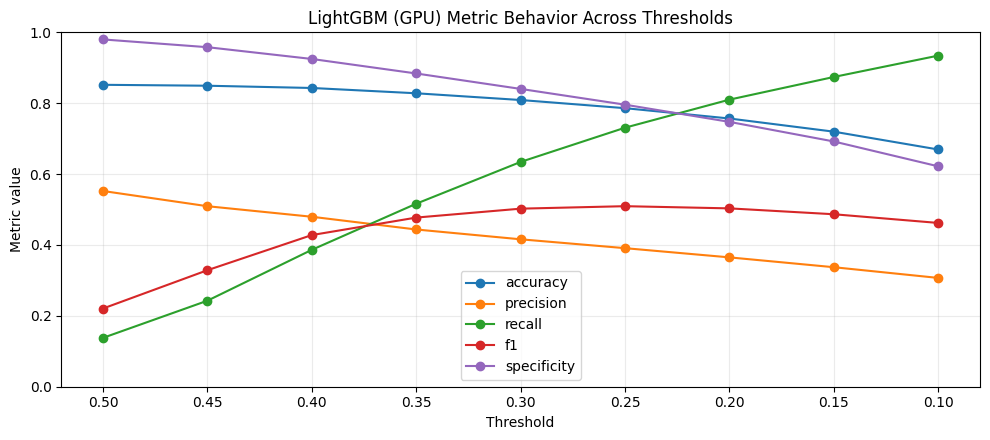

In [6]:
plt.figure(figsize=(10, 4.5))
for metric in ['accuracy', 'precision', 'recall', 'f1', 'specificity']:
    plt.plot(threshold_df['threshold'], threshold_df[metric], marker='o', label=metric)
plt.gca().invert_xaxis()
plt.ylim(0.0, 1.0)
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('LightGBM (GPU) Metric Behavior Across Thresholds')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

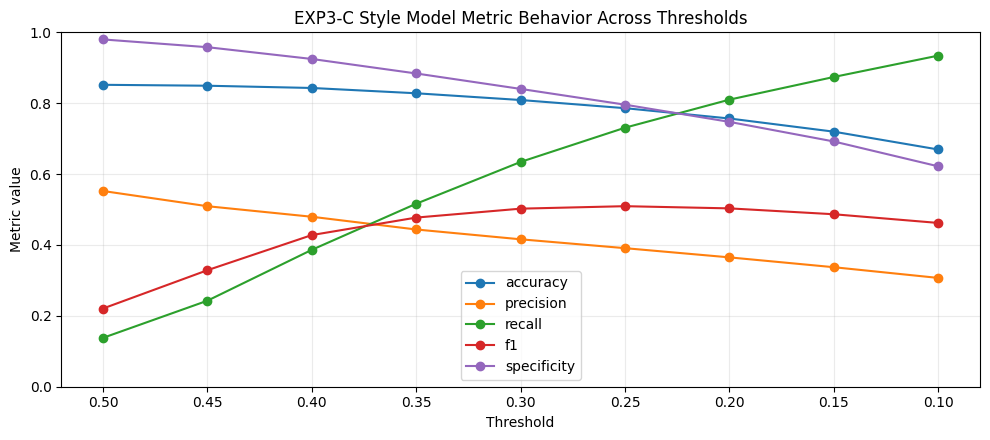

In [7]:
plt.figure(figsize=(10, 4.5))
for metric in ['accuracy', 'precision', 'recall', 'f1', 'specificity']:
    plt.plot(threshold_df['threshold'], threshold_df[metric], marker='o', label=metric)
plt.gca().invert_xaxis()
plt.ylim(0.0, 1.0)
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('EXP3-C Style Model Metric Behavior Across Thresholds')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()